In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

# 데이터 불러오기
penguins = sns.load_dataset('penguins')

In [3]:
# 1) 결측치 제거 (간결함을 위해 결측치가 포함된 행 삭제)
df = penguins.dropna()

# 2) 범주형 독립변수 인코딩 (island, sex)
# 'species'는 종속변수(Target)이므로 나중에 처리
df = pd.get_dummies(df, columns=['island', 'sex'], drop_first=True)

# 3) 독립변수(X)와 종속변수(y) 분리
X = df.drop('species', axis=1)
y = df['species']

# 4) 데이터 분할 (훈련셋 7, 테스트셋 3)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 5) 데이터 스케일링 (로지스틱 회귀는 거리 기반 계산이 포함되므로 정규화가 중요함)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [4]:
# 모델 생성 (multi_class='multinomial' 명시)
# solver='lbfgs'는 다중 분류에서 가장 안정적인 성능을 보입니다.
model = LogisticRegression(multi_class='multinomial', solver='lbfgs', max_iter=1000)

# 모델 학습
model.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=1000, multi_class='multinomial')

--- Classification Report ---
              precision    recall  f1-score   support

      Adelie       0.98      1.00      0.99        48
   Chinstrap       1.00      0.94      0.97        18
      Gentoo       1.00      1.00      1.00        34

    accuracy                           0.99       100
   macro avg       0.99      0.98      0.99       100
weighted avg       0.99      0.99      0.99       100



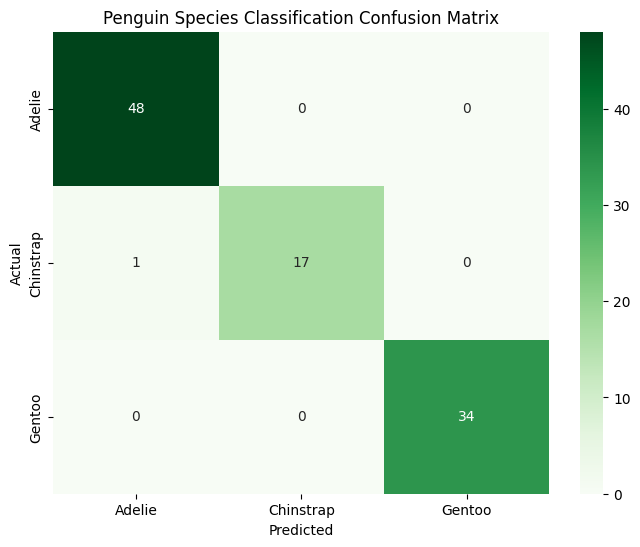

In [5]:
# 예측
y_pred = model.predict(X_test_scaled)

# 결과 리포트 출력
print("--- Classification Report ---")
print(classification_report(y_test, y_pred))

# 혼동 행렬 시각화
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', 
            xticklabels=model.classes_, yticklabels=model.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Penguin Species Classification Confusion Matrix')
plt.show()

In [6]:
import numpy as np
import pandas as pd

# 계수(Coefficient)와 변수 이름 매칭
feature_names = X.columns
# Gentoo 클래스는 보통 인덱스 2에 위치 (Adelie:0, Chinstrap:1, Gentoo:2)
gentoo_coef = model.coef_[2] 

# 데이터프레임으로 정리
coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Log-Odds (Beta)': gentoo_coef,
    'Odds Ratio (exp(Beta))': np.exp(gentoo_coef)
}).sort_values(by='Log-Odds (Beta)', ascending=False)

print(coef_df)

             Feature  Log-Odds (Beta)  Odds Ratio (exp(Beta))
2  flipper_length_mm         0.869534                2.385799
3        body_mass_g         0.851263                2.342603
0     bill_length_mm         0.423270                1.526946
6           sex_Male        -0.140877                0.868596
5   island_Torgersen        -0.250953                0.778059
4       island_Dream        -0.809342                0.445151
1      bill_depth_mm        -1.177151                0.308155
